# ER graph: SHD vs update budget for CD_A and CD_A_epoch

这个 notebook 只比较两个算法：

- `CD_A`: `dag_coordinate_descent_l0`
- `CD_A_epoch`: `dag_coordinate_descent_l0_epoch`

关键点：一个 `CD_A_epoch` 的 epoch 包含

- `d(d-1)/2` 次非对角 pair 更新
- `d` 次对角更新

所以总共是 `d(d+1)/2` 次底层 update。为了公平比较，这里把横轴统一成 **update budget**，而不是直接拿 iter 和 epoch 混着比。

底层代码已经支持保存每个 update 后的图历史，因此每个 trial / algorithm 只需要跑一次到 `max(update_budgets)`，再直接读取历史计算 SHD。

In [32]:
import os
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display


def find_repo_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / 'synthetic_dataset.py').exists() and (candidate / 'coordinate_descent').exists():
            return candidate
    raise RuntimeError('Cannot locate repo root from current working directory.')


ROOT = find_repo_root(Path.cwd())
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

from synthetic_dataset import SyntheticDataset
from coordinate_descent.coordinate0 import (
    dag_coordinate_descent_l0,
    dag_coordinate_descent_l0_epoch,
)
from coordinate_descent.cd_greedy_A import dag_greedy_A

plt.rcParams['figure.figsize'] = (9, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.25

print('ROOT =', ROOT)


ROOT = C:\Users\super\DAG


In [33]:
def make_update_budgets(max_budget=20000):
    early = list(range(1, 101))
    middle = list(range(200, 2001, 200))
    late = np.unique(np.geomspace(2500, max_budget, 18).astype(int)).tolist()
    return sorted(set(early + middle + late + [max_budget]))


CONFIG = {
    'd': 20,
    'n': 20000,
    'degree': 2.0,
    'noise_type': 'gaussian_ev',
    'B_scale': 1.0,
    'threshold': 0.05,
    'lambda_l0': 0.2,
    'n_trials': 3,
    'master_seed': 20260405,
    'update_budgets': make_update_budgets(max_budget=50000),
    'save_results': True,
    # --- Early-stopping config ---
    # early_stop: True  → 开启显式相对改进早停
    # es_check_every: 检查间隔步数（None → d*(d+1)//2）
    # es_tol: 相对改进阈值，低于此值才计入 patience
    # es_patience: 连续低于 tol 的次数达到后停止
    # es_min_steps: 热身步数，热身期间不触发停止（None → check_every*10）
    'early_stop': True,
    'es_check_every': None,
    'es_tol': 1e-4,
    'es_patience': 10,
    'es_min_steps': None,
}

UPDATES_PER_EPOCH = CONFIG['d'] * (CONFIG['d'] + 1) // 2
MAX_UPDATE_BUDGET = max(CONFIG['update_budgets'])
MAX_EPOCHS = int(np.ceil(MAX_UPDATE_BUDGET / UPDATES_PER_EPOCH))

print('updates_per_epoch =', UPDATES_PER_EPOCH)
print('max_update_budget =', MAX_UPDATE_BUDGET)
print('max_epochs_for_CD_A_epoch =', MAX_EPOCHS)
print(f'early_stop={CONFIG["early_stop"]}  tol={CONFIG["es_tol"]}  patience={CONFIG["es_patience"]}')
CONFIG


updates_per_epoch = 210
max_update_budget = 50000
max_epochs_for_CD_A_epoch = 239
early_stop=True  tol=0.0001  patience=10


{'d': 20,
 'n': 20000,
 'degree': 2.0,
 'noise_type': 'gaussian_ev',
 'B_scale': 1.0,
 'threshold': 0.05,
 'lambda_l0': 0.2,
 'n_trials': 3,
 'master_seed': 20260405,
 'update_budgets': [1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40,
  41,
  42,
  43,
  44,
  45,
  46,
  47,
  48,
  49,
  50,
  51,
  52,
  53,
  54,
  55,
  56,
  57,
  58,
  59,
  60,
  61,
  62,
  63,
  64,
  65,
  66,
  67,
  68,
  69,
  70,
  71,
  72,
  73,
  74,
  75,
  76,
  77,
  78,
  79,
  80,
  81,
  82,
  83,
  84,
  85,
  86,
  87,
  88,
  89,
  90,
  91,
  92,
  93,
  94,
  95,
  96,
  97,
  98,
  99,
  100,
  200,
  400,
  600,
  800,
  1000,
  1200,
  1400,
  1600,
  1800,
  2000,
  2500,
  2981,
  3556,
  4241,
  5059,
  6033,
  7196,
  8583,
  10237,
  12210,
  14563,
  17369,
  20716,
  24708,
  29469,
  35148,
  41921,
  

In [34]:
def weight_to_binary_adj(W, threshold=0.0):
    G = (np.abs(W) > threshold).astype(int)
    np.fill_diagonal(G, 0)
    return G


def shd_score(G_true, G_est):
    G_true = np.asarray(G_true, dtype=int)
    G_est = np.asarray(G_est, dtype=int)
    return int(np.sum(np.abs(G_true - G_est)))


def make_er_trial(data_seed, cfg):
    dataset = SyntheticDataset(
        n=cfg['n'],
        d=cfg['d'],
        graph_type='ER',
        degree=cfg['degree'],
        noise_type=cfg['noise_type'],
        B_scale=cfg['B_scale'],
        seed=int(data_seed),
    )
    X = dataset.X
    S = X.T @ X / X.shape[0]
    G_true = weight_to_binary_adj(dataset.B, threshold=0.0)
    return dataset, S, G_true


def run_cd_a_full_history(S, max_budget, seed, cfg):
    return dag_coordinate_descent_l0(
        S=S,
        T=int(max_budget),
        seed=int(seed),
        threshold=cfg['threshold'],
        lambda_l0=cfg['lambda_l0'],
        return_history=True,
        return_graph_history=True,
        early_stop=cfg.get('early_stop', False),
        check_every=cfg.get('es_check_every', None),
        tol=cfg.get('es_tol', 1e-4),
        patience=cfg.get('es_patience', 10),
        min_steps=cfg.get('es_min_steps', None),
    )


def run_cd_a_epoch_full_history(S, max_budget, seed, cfg):
    updates_per_epoch = cfg['d'] * (cfg['d'] + 1) // 2
    max_epochs = int(np.ceil(max_budget / updates_per_epoch))
    return dag_coordinate_descent_l0_epoch(
        S=S,
        n_epochs=max_epochs,
        seed=int(seed),
        threshold=cfg['threshold'],
        lambda_l0=cfg['lambda_l0'],
        tol=1e-4,
        patience=max_epochs + 1,
        min_epochs=max_epochs + 1,
        verbose=False,
        return_graph_history=True,
        graph_history_granularity='update',
    )


def run_greedy_cd_a_full_history(S, max_budget, seed, cfg):
    # dag_greedy_A has an always-on implicit stop (no positive-gain candidate).
    # early_stop=True additionally enables relative-improvement patience stopping.
    return dag_greedy_A(
        S=S,
        T=int(max_budget),
        seed=int(seed),
        threshold=cfg['threshold'],
        lambda_l0=cfg['lambda_l0'],
        return_history=True,
        return_graph_history=True,
        early_stop=cfg.get('early_stop', False),
        check_every=cfg.get('es_check_every', None),
        tol=cfg.get('es_tol', 1e-4),
        patience=cfg.get('es_patience', 10),
        min_steps=cfg.get('es_min_steps', None),
    )


ALGORITHM_RUNNERS = {
    'CD_A': run_cd_a_full_history,
    'Greedy_CD_A': run_greedy_cd_a_full_history,
}

ALGORITHM_ORDER = ['CD_A', 'Greedy_CD_A']
ALGORITHM_COLORS = {
    'CD_A': 'steelblue',
    'Greedy_CD_A': 'darkorange',
}


In [35]:
rng = np.random.default_rng(CONFIG['master_seed'])
trial_seeds = rng.integers(low=0, high=10**9, size=CONFIG['n_trials'])

rows = []
run_rows = []

for trial_id, data_seed in enumerate(trial_seeds, start=1):
    dataset, S, G_true = make_er_trial(int(data_seed), CONFIG)
    print(f'[trial {trial_id:02d}/{CONFIG["n_trials"]}] seed={int(data_seed)} | true_edges={int(G_true.sum())}')

    for algorithm in ALGORITHM_ORDER:
        runner = ALGORITHM_RUNNERS[algorithm]
        t0 = time.perf_counter()
        A_est, G_final, final_obj, history, graph_history = runner(S, MAX_UPDATE_BUDGET, int(data_seed), CONFIG)
        t1 = time.perf_counter()

        actual_steps = int(len(graph_history))
        stopped_early_run = int(actual_steps < MAX_UPDATE_BUDGET)

        run_rows.append({
            'trial_id': trial_id,
            'data_seed': int(data_seed),
            'algorithm': algorithm,
            'history_len': int(len(history)),
            'graph_history_len': actual_steps,
            'actual_steps': actual_steps,
            'stopped_early': stopped_early_run,
            'full_run_runtime_sec': float(t1 - t0),
            'final_objective': float(final_obj),
            'final_edges': int(np.sum(G_final)),
        })

        print(
            f'  [{algorithm}]  steps={actual_steps}/{MAX_UPDATE_BUDGET}'
            f'{"  (early stop)" if stopped_early_run else ""}  rt={t1-t0:.2f}s'
        )

        effective_max_budget = actual_steps
        for budget in CONFIG['update_budgets']:
            eff_budget = min(int(budget), int(effective_max_budget))
            G_t = np.asarray(graph_history[eff_budget - 1], dtype=int)

            # score lookup
            if algorithm == 'CD_A':
                # history is per-step, length == actual_steps
                score_t = float(history[eff_budget - 1])
            elif algorithm == 'Greedy_CD_A':
                # greedy: each accepted step = 1 update; may stop before MAX_UPDATE_BUDGET
                score_t = float(history[min(eff_budget, len(history)) - 1])
            else:
                # CD_A_epoch: history is per-epoch
                epoch_idx = min((eff_budget - 1) // UPDATES_PER_EPOCH, len(history) - 1)
                score_t = float(history[epoch_idx])

            rows.append({
                'trial_id': trial_id,
                'data_seed': int(data_seed),
                'algorithm': algorithm,
                'update_budget': int(budget),
                'effective_update_budget': int(eff_budget),
                'stopped_early': int(eff_budget < int(budget)),
                'shd': shd_score(G_true, G_t),
                'score': score_t,
                'n_edges_true': int(G_true.sum()),
                'n_edges_est': int(np.sum(G_t)),
            })

df = pd.DataFrame(rows)
df_runs = pd.DataFrame(run_rows)

display(df.head())
display(df_runs)


[trial 01/3] seed=218858081 | true_edges=17
  [CD_A]  steps=30240/50000  (early stop)  rt=10.13s
  [Greedy_CD_A]  steps=3266/50000  (early stop)  rt=23.80s
[trial 02/3] seed=457189129 | true_edges=26
  [CD_A]  steps=20580/50000  (early stop)  rt=6.33s
  [Greedy_CD_A]  steps=3990/50000  (early stop)  rt=27.74s
[trial 03/3] seed=312377554 | true_edges=25
  [CD_A]  steps=30660/50000  (early stop)  rt=10.29s
  [Greedy_CD_A]  steps=3990/50000  (early stop)  rt=27.95s


,trial_id,data_seed,algorithm,update_budget,effective_update_budget,stopped_early,shd,score,n_edges_true,n_edges_est
0,1,218858081,CD_A,1,1,0,17,232.863435,17,0
1,1,218858081,CD_A,2,2,0,18,226.392623,17,1
2,1,218858081,CD_A,3,3,0,19,220.234175,17,2
3,1,218858081,CD_A,4,4,0,20,211.224816,17,3
4,1,218858081,CD_A,5,5,0,21,104.897716,17,4


,trial_id,data_seed,algorithm,history_len,graph_history_len,actual_steps,stopped_early,full_run_runtime_sec,final_objective,final_edges
0,1,218858081,CD_A,30240,30240,30240,1,10.126899,21.814890,19
1,1,218858081,Greedy_CD_A,3266,3266,3266,1,23.801551,22.353833,18
2,2,457189129,CD_A,20580,20580,20580,1,6.328514,21.961549,25
3,2,457189129,Greedy_CD_A,3990,3990,3990,1,27.735284,23.826062,28
4,3,312377554,CD_A,30660,30660,30660,1,10.294234,22.228426,25
5,3,312377554,Greedy_CD_A,3990,3990,3990,1,27.947863,24.795063,29


In [36]:
summary = (
    df.groupby(['algorithm', 'update_budget'], as_index=False)
      .agg(
          shd_mean=('shd', 'mean'),
          shd_std=('shd', 'std'),
          shd_min=('shd', 'min'),
          shd_max=('shd', 'max'),
          score_mean=('score', 'mean'),
          score_std=('score', 'std'),
          effective_update_budget_mean=('effective_update_budget', 'mean'),
          stopped_early_rate=('stopped_early', 'mean'),
      )
)

best_by_alg = (
    summary.loc[summary.groupby('algorithm')['shd_mean'].idxmin()]
           .sort_values(['shd_mean', 'algorithm'])
           .reset_index(drop=True)
)

display(summary.head(12))
display(best_by_alg)

,algorithm,update_budget,shd_mean,shd_std,shd_min,shd_max,score_mean,score_std,effective_update_budget_mean,stopped_early_rate
0,CD_A,1,23.000000,5.291503,17,27,251.331727,54.711848,1.0,0.0
1,CD_A,2,23.000000,4.358899,18,26,249.050494,56.054947,2.0,0.0
2,CD_A,3,23.333333,3.785939,19,26,244.740622,59.109139,3.0,0.0
3,CD_A,4,23.666667,3.214550,20,26,241.737502,61.169714,4.0,0.0
4,CD_A,5,24.000000,2.645751,21,26,206.295135,103.704115,5.0,0.0
5,CD_A,6,24.333333,3.055050,21,27,205.332564,102.233122,6.0,0.0
6,CD_A,7,24.333333,3.055050,21,27,205.332564,102.233122,7.0,0.0
7,CD_A,8,24.333333,3.055050,21,27,205.332564,102.233122,8.0,0.0
8,CD_A,9,24.000000,2.645751,21,26,198.723088,92.312928,9.0,0.0
9,CD_A,10,24.333333,3.055050,21,27,196.018063,88.359551,10.0,0.0


,algorithm,update_budget,shd_mean,shd_std,shd_min,shd_max,score_mean,score_std,effective_update_budget_mean,stopped_early_rate
0,CD_A,24708,19.000000,2.645751,17,22,22.027375,0.217782,23332.0,0.333333
1,Greedy_CD_A,1,22.666667,4.932883,17,26,155.260436,52.534221,1.0,0.000000


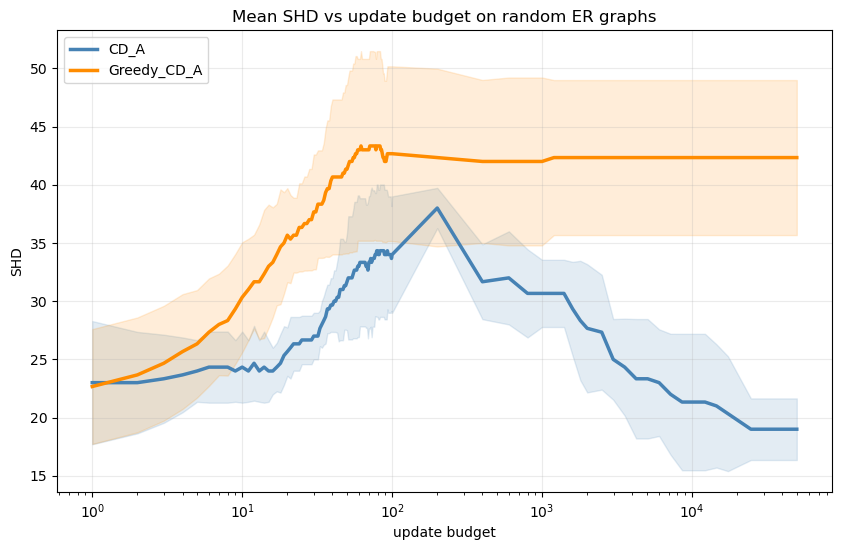

In [43]:
fig, ax = plt.subplots(figsize=(10, 6))

for algorithm in ALGORITHM_ORDER:
    sub = summary[summary['algorithm'] == algorithm].sort_values('update_budget')
    x = sub['update_budget'].to_numpy()
    y = sub['shd_mean'].to_numpy()
    yerr = np.nan_to_num(sub['shd_std'].to_numpy(), nan=0.0)
    color = ALGORITHM_COLORS[algorithm]

    ax.plot(x, y, color=color, linewidth=2.5, label=algorithm)
    ax.fill_between(x, y - yerr, y + yerr, color=color, alpha=0.15)

ax.set_title('Mean SHD vs update budget on random ER graphs')
ax.set_xlabel('update budget')
ax.set_xscale('log')
ax.set_ylabel('SHD')
ax.legend()
plt.show()

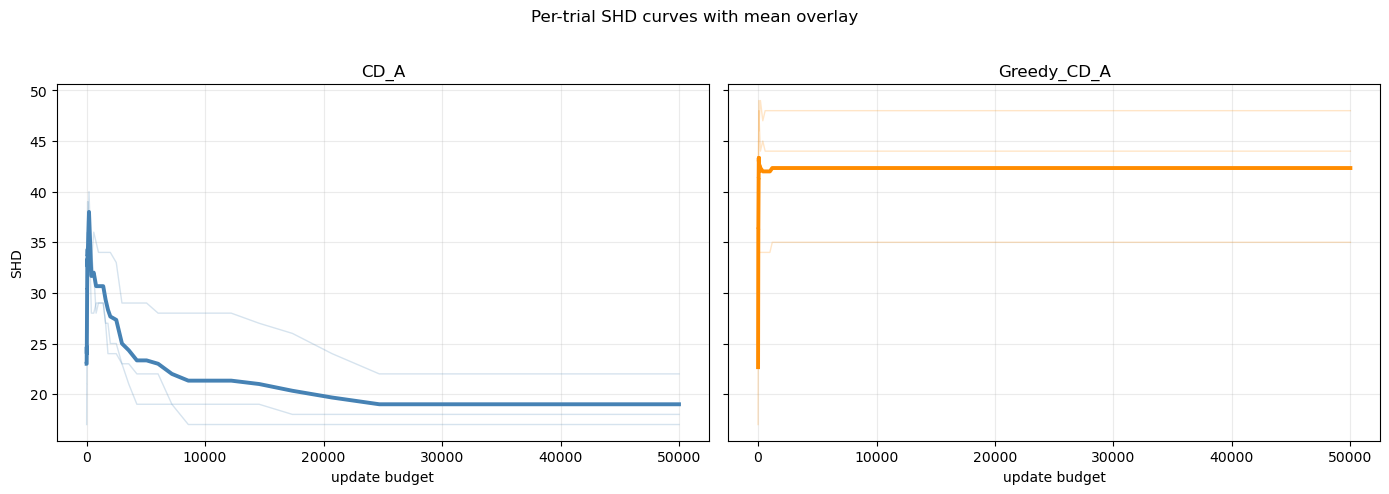

In [38]:
fig, axes = plt.subplots(1, len(ALGORITHM_ORDER), figsize=(7 * len(ALGORITHM_ORDER), 4.8), sharey=True)

for ax, algorithm in zip(axes.flat, ALGORITHM_ORDER):
    color = ALGORITHM_COLORS[algorithm]
    trial_sub = df[df['algorithm'] == algorithm].sort_values(['trial_id', 'update_budget'])
    for trial_id, one_trial in trial_sub.groupby('trial_id'):
        ax.plot(
            one_trial['update_budget'],
            one_trial['shd'],
            color=color,
            alpha=0.22,
            linewidth=1.0,
        )

    mean_sub = summary[summary['algorithm'] == algorithm].sort_values('update_budget')
    ax.plot(
        mean_sub['update_budget'],
        mean_sub['shd_mean'],
        color=color,
        linewidth=2.8,
    )
    ax.set_title(algorithm)
    ax.set_xlabel('update budget')

axes[0].set_ylabel('SHD')
fig.suptitle('Per-trial SHD curves with mean overlay', y=1.02)
fig.tight_layout()
plt.show()


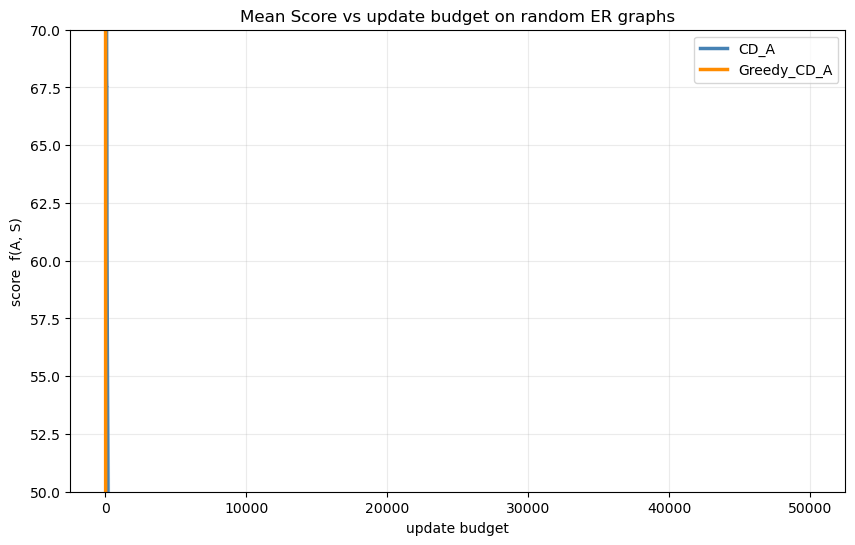

In [39]:
fig, ax = plt.subplots(figsize=(10, 6))

for algorithm in ALGORITHM_ORDER:
    sub = summary[summary['algorithm'] == algorithm].sort_values('update_budget')
    x = sub['update_budget'].to_numpy()
    y = sub['score_mean'].to_numpy()
    yerr = np.nan_to_num(sub['score_std'].to_numpy(), nan=0.0)
    color = ALGORITHM_COLORS[algorithm]

    ax.plot(x, y, color=color, linewidth=2.5, label=algorithm)
    ax.fill_between(x, y - yerr, y + yerr, color=color, alpha=0.15)

ax.set_title('Mean Score vs update budget on random ER graphs')
ax.set_xlabel('update budget')
ax.set_ylabel('score  f(A, S)')
ax.set_ylim(50, 70)
ax.legend()
plt.show()

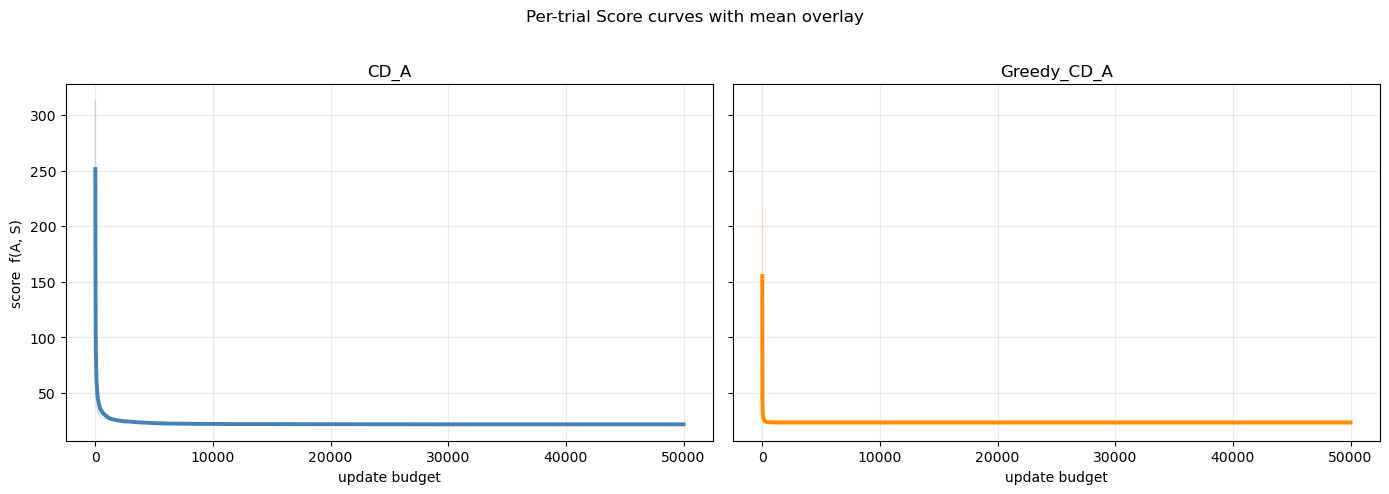

In [40]:
fig, axes = plt.subplots(1, len(ALGORITHM_ORDER), figsize=(7 * len(ALGORITHM_ORDER), 4.8), sharey=True)

for ax, algorithm in zip(axes.flat, ALGORITHM_ORDER):
    color = ALGORITHM_COLORS[algorithm]
    trial_sub = df[df['algorithm'] == algorithm].sort_values(['trial_id', 'update_budget'])
    for trial_id, one_trial in trial_sub.groupby('trial_id'):
        ax.plot(
            one_trial['update_budget'],
            one_trial['score'],
            color=color,
            alpha=0.22,
            linewidth=1.0,
        )

    mean_sub = summary[summary['algorithm'] == algorithm].sort_values('update_budget')
    ax.plot(
        mean_sub['update_budget'],
        mean_sub['score_mean'],
        color=color,
        linewidth=2.8,
    )
    ax.set_title(algorithm)
    ax.set_xlabel('update budget')

axes[0].set_ylabel('score  f(A, S)')
fig.suptitle('Per-trial Score curves with mean overlay', y=1.02)
fig.tight_layout()
plt.show()


=== Greedy_CD_A convergence (accepted updates before implicit stop) ===
 trial_id  graph_history_len  full_run_runtime_sec  final_edges
        1               3266             23.801551           18
        2               3990             27.735284           28
        3               3990             27.947863           29



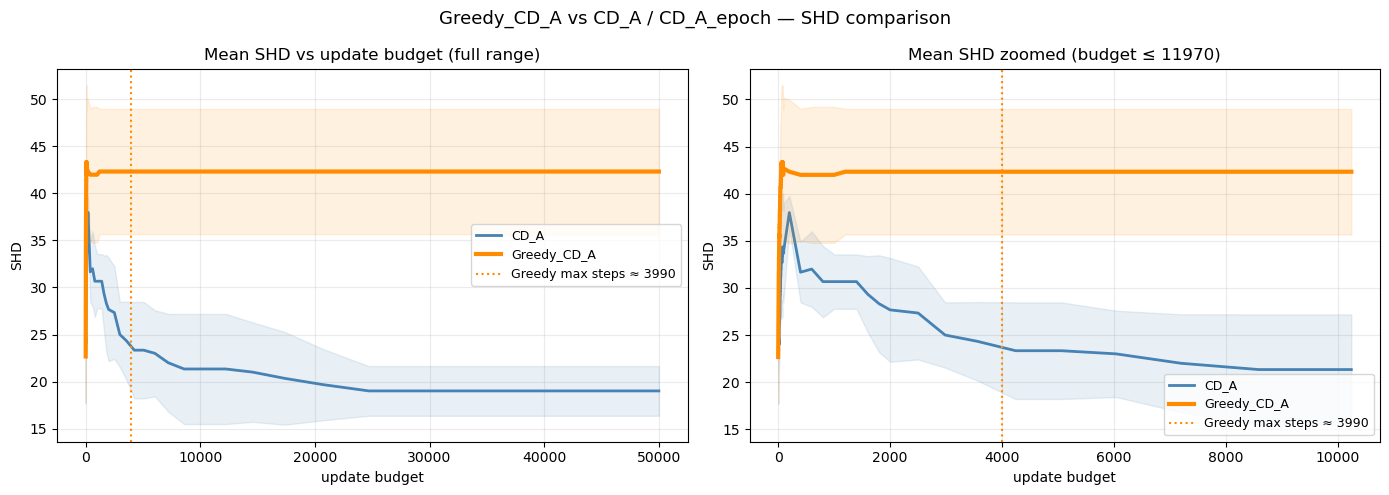

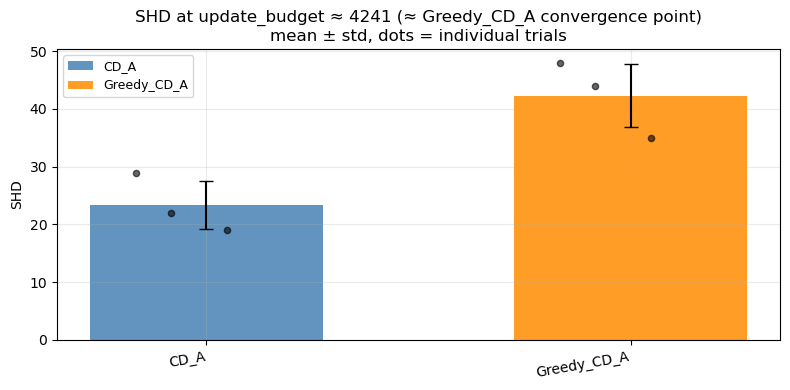

In [41]:
# Greedy_CD_A: convergence profile and head-to-head comparison
# ---------------------------------------------------------------
# 1. Show actual convergence steps for Greedy_CD_A (how many accepted
#    updates before implicit stop).
# 2. Direct SHD comparison: Greedy_CD_A vs CD_A and CD_A_epoch at
#    the same update budgets.

greedy_runs = df_runs[df_runs['algorithm'] == 'Greedy_CD_A']
if greedy_runs.empty:
    print('No Greedy_CD_A data — run the data-collection cell first.')
else:
    print('=== Greedy_CD_A convergence (accepted updates before implicit stop) ===')
    print(greedy_runs[['trial_id', 'graph_history_len', 'full_run_runtime_sec', 'final_edges']].to_string(index=False))
    print()

    # -- Plot 1: SHD vs update budget, all algorithms overlaid (zoomed to greedy range) --
    greedy_max_steps = int(greedy_runs['graph_history_len'].max())

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Left: full x-range
    ax = axes[0]
    for alg in ALGORITHM_ORDER:
        sub = summary[summary['algorithm'] == alg].sort_values('update_budget')
        x = sub['update_budget'].to_numpy()
        y = sub['shd_mean'].to_numpy()
        yerr = np.nan_to_num(sub['shd_std'].to_numpy(), nan=0.0)
        color = ALGORITHM_COLORS[alg]
        lw = 3.0 if alg == 'Greedy_CD_A' else 2.0
        zorder = 3 if alg == 'Greedy_CD_A' else 2
        ax.plot(x, y, color=color, linewidth=lw, label=alg, zorder=zorder)
        ax.fill_between(x, y - yerr, y + yerr, color=color, alpha=0.12, zorder=zorder)
    ax.axvline(greedy_max_steps, color='darkorange', linestyle=':', linewidth=1.5,
               label=f'Greedy max steps ≈ {greedy_max_steps}')
    ax.set_title('Mean SHD vs update budget (full range)')
    ax.set_xlabel('update budget')
    ax.set_ylabel('SHD')
    ax.legend(fontsize=9)

    # Right: zoomed to greedy convergence range × 3
    ax = axes[1]
    zoom_limit = max(greedy_max_steps * 3, 500)
    for alg in ALGORITHM_ORDER:
        sub = (
            summary[summary['algorithm'] == alg]
            .sort_values('update_budget')
            .pipe(lambda d: d[d['update_budget'] <= zoom_limit])
        )
        x = sub['update_budget'].to_numpy()
        y = sub['shd_mean'].to_numpy()
        yerr = np.nan_to_num(sub['shd_std'].to_numpy(), nan=0.0)
        color = ALGORITHM_COLORS[alg]
        lw = 3.0 if alg == 'Greedy_CD_A' else 2.0
        zorder = 3 if alg == 'Greedy_CD_A' else 2
        ax.plot(x, y, color=color, linewidth=lw, label=alg, zorder=zorder)
        ax.fill_between(x, y - yerr, y + yerr, color=color, alpha=0.12, zorder=zorder)
    ax.axvline(greedy_max_steps, color='darkorange', linestyle=':', linewidth=1.5,
               label=f'Greedy max steps ≈ {greedy_max_steps}')
    ax.set_title(f'Mean SHD zoomed (budget ≤ {zoom_limit})')
    ax.set_xlabel('update budget')
    ax.set_ylabel('SHD')
    ax.legend(fontsize=9)

    fig.suptitle('Greedy_CD_A vs CD_A / CD_A_epoch — SHD comparison', fontsize=13)
    plt.tight_layout()
    plt.show()

    # -- Plot 2: final SHD bar chart at greedy's convergence budget --
    # Compare all algorithms at the update budget closest to greedy's max steps.
    closest_budget = min(CONFIG['update_budgets'], key=lambda b: abs(b - greedy_max_steps))
    slice_df = df[df['update_budget'] == closest_budget]

    fig, ax = plt.subplots(figsize=(8, 4))
    x_pos = np.arange(len(ALGORITHM_ORDER))
    for xi, alg in enumerate(ALGORITHM_ORDER):
        sub = slice_df[slice_df['algorithm'] == alg]['shd']
        mean_shd = sub.mean()
        std_shd = sub.std(ddof=0)
        color = ALGORITHM_COLORS[alg]
        ax.bar(xi, mean_shd, yerr=std_shd, capsize=5, color=color, alpha=0.85,
               label=alg, width=0.55)
        ax.scatter(np.full(len(sub), xi) + np.random.default_rng(0).uniform(-0.18, 0.18, len(sub)),
                   sub.values, color='k', s=20, zorder=3, alpha=0.6)

    ax.set_xticks(x_pos)
    ax.set_xticklabels(ALGORITHM_ORDER, rotation=10, ha='right')
    ax.set_ylabel('SHD')
    ax.set_title(f'SHD at update_budget ≈ {closest_budget} (≈ Greedy_CD_A convergence point)\nmean ± std, dots = individual trials')
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()


In [42]:
if CONFIG['save_results']:
    outdir = ROOT / 'experiments' / 'results'
    outdir.mkdir(parents=True, exist_ok=True)
    tag = (
        f"er_cd_A_vs_epoch_shd_vs_update_budget_"
        f"d{CONFIG['d']}_n{CONFIG['n']}_deg{CONFIG['degree']}_trials{CONFIG['n_trials']}"
    )
    raw_path = outdir / f'{tag}_raw.csv'
    summary_path = outdir / f'{tag}_summary.csv'
    runs_path = outdir / f'{tag}_full_runs.csv'
    df.to_csv(raw_path, index=False)
    summary.to_csv(summary_path, index=False)
    df_runs.to_csv(runs_path, index=False)
    print('saved raw      ->', raw_path)
    print('saved summary  ->', summary_path)
    print('saved run info ->', runs_path)

saved raw      -> C:\Users\super\DAG\experiments\results\er_cd_A_vs_epoch_shd_vs_update_budget_d20_n20000_deg2.0_trials3_raw.csv
saved summary  -> C:\Users\super\DAG\experiments\results\er_cd_A_vs_epoch_shd_vs_update_budget_d20_n20000_deg2.0_trials3_summary.csv
saved run info -> C:\Users\super\DAG\experiments\results\er_cd_A_vs_epoch_shd_vs_update_budget_d20_n20000_deg2.0_trials3_full_runs.csv
